In [55]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests


In [56]:
#‘tipsʼ sample dataset, which is available as part of the seaborn (sns) package

#information about tips at a restaurant, including meal time, party size, 
#gender of customer, total bill amount, and tip amount

tips = sns.load_dataset("tips")
print(tips)


     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

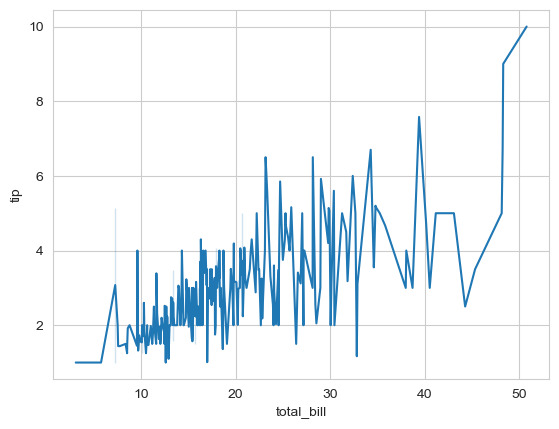

In [57]:
#can use premade styles to alter the appearance of our plot
#styles like ‘darkgridʼ,‘whitegridʼ,‘darkʼ,‘whiteʼ,‘ticksʼ
sns.set_style('whitegrid')

#simple line plot of tip amount vs total bill

sns.lineplot(data=tips, # choose our dataset
             x='total_bill', # define our x variable
             y='tip') # define our y variable

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

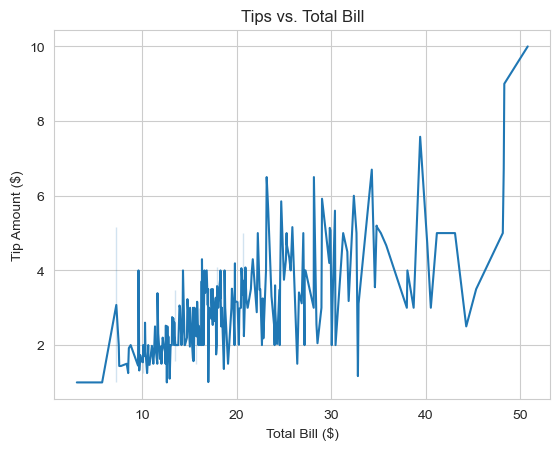

In [58]:
#Seaborn can do many of the same things as matplotlib,
#  like adding labels We do thisusing the "set."" function

tipgraph = sns.lineplot(data=tips,x='total_bill',y='tip')
tipgraph.set(title='Tips vs. Total Bill',xlabel='Total Bill ($)',ylabel='Tip Amount ($)')


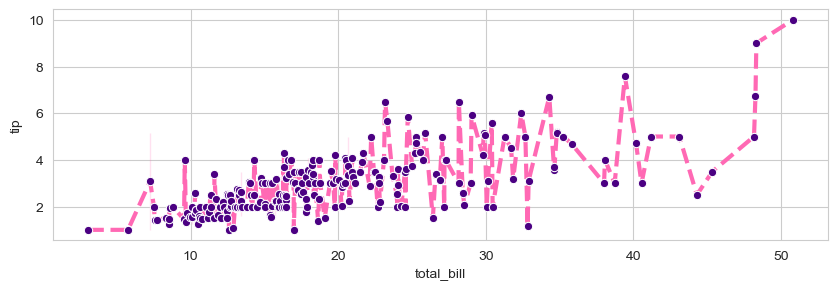

In [59]:
#Modify aesthetic elements
#we can use the subplots function to change figure size

fig = plt.subplots(figsize=(10, 3))
#change colour, marker style, and line style

tipgraph = sns.lineplot(data=tips,x='total_bill',
                        y='tip',color = 'hotpink',
                        linestyle = '--',
                        linewidth = 3,
                        marker = 'o',
                        markerfacecolor = 'indigo')




[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

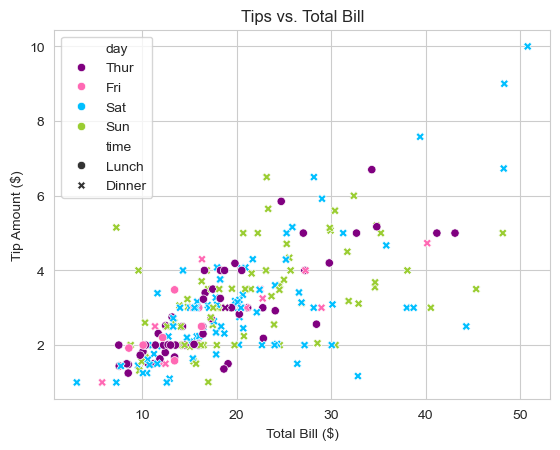

In [60]:
#Add multiple variables
#Seaborn makes it very easy to represent multiple variables with different visual elements of our graph

#fig = plt.subplots(figsize=(10, 3))

tipgraph = sns.scatterplot(data=tips,
                            x='total_bill',
                            y='tip',
                            style = 'time',
                            hue ='day',
                            palette = ['purple','hotpink','deepskyblue','yellowgreen'])

tipgraph.set(title='Tips vs. Total Bill',
            xlabel='Total Bill ($)',
            ylabel='Tip Amount ($)')

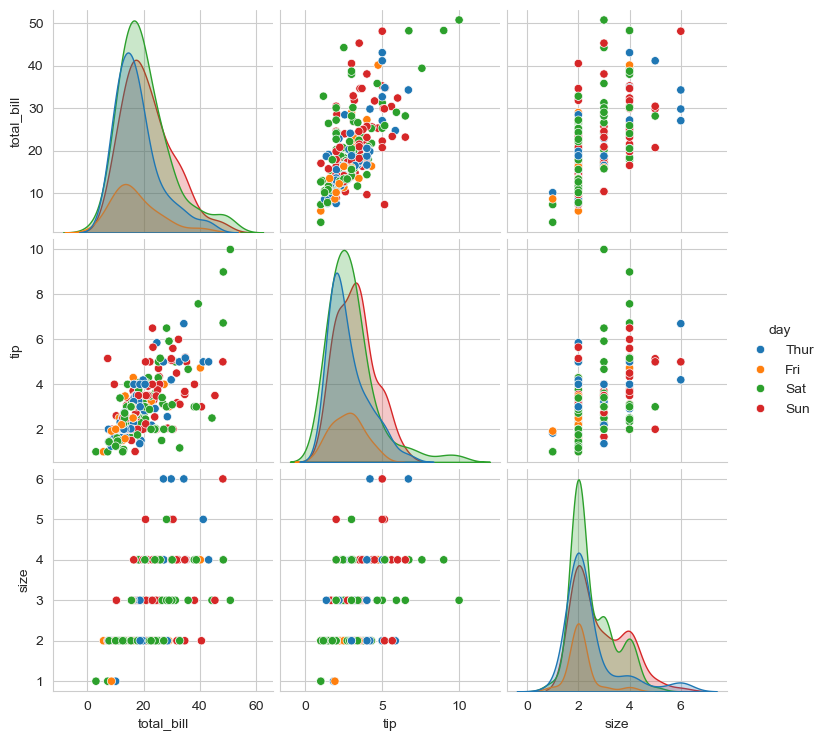

In [61]:
#Pairplot
#pairplot is another convenient way to compare variables
#no categorical, just numbers

sns.pairplot(data = tips, hue = 'day')


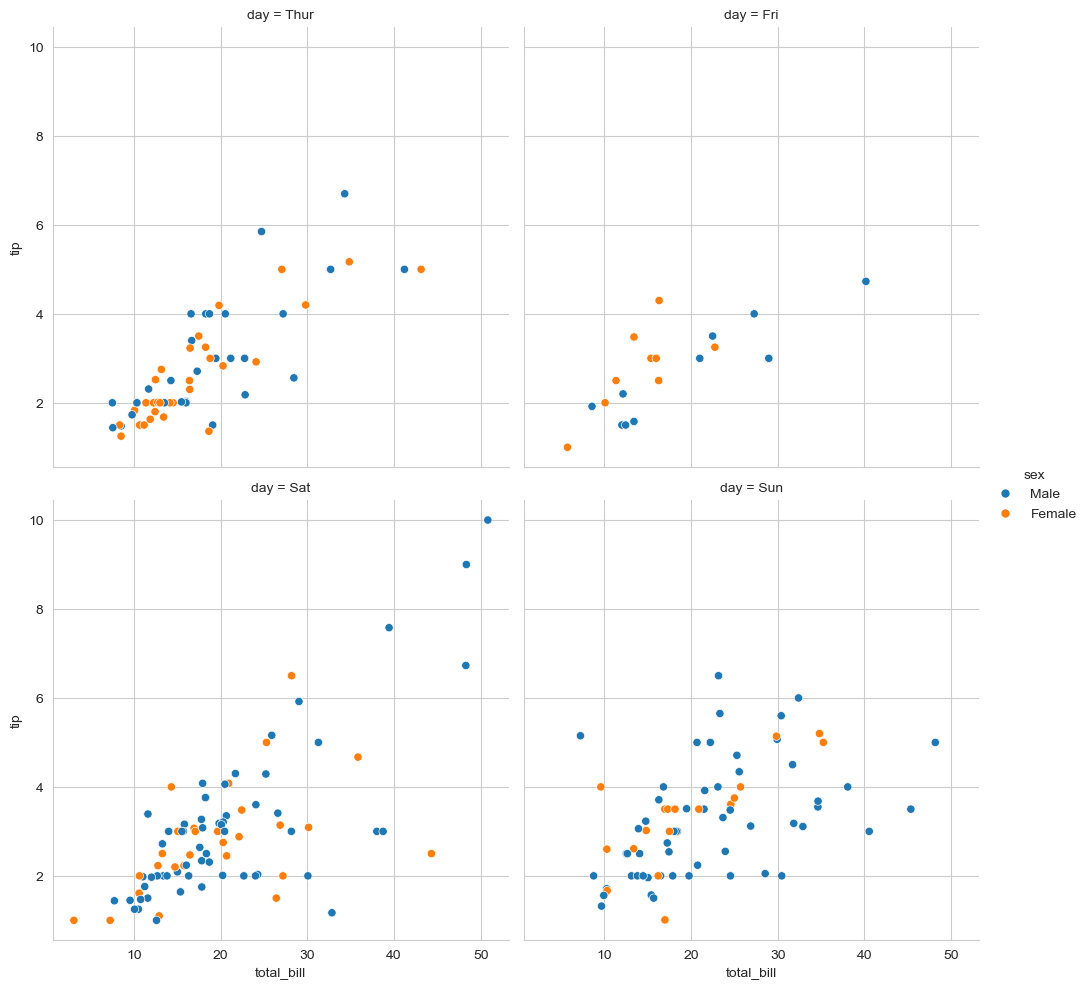

In [62]:
#Relplot
#relplot also lets us explore specific levels within variables

daysplot = sns.relplot(data=tips,
                       x="total_bill",
                       y="tip",
                       hue="sex",
                       col="day",
                       kind="scatter",
                       col_wrap=2)


#total bill vs tip across days in two columns and color are based on sex

In [63]:
#Plotly
#import our package and make some sample data

import plotly.graph_objects as go # 'go' is 'graph objects’

x1 = np.array(["Luffy","Zoro","Nami","Usopp","Sanji"])
y1 = np.array([110, 180, 240, 99, 220])



In [64]:
#Making our plot
#Plotly syntax is different from matplotlib/seaborn 


# First, make our figure
graph = go.Figure()

#choose our plot type (bar) and our data
graph.add_trace(go.Bar(x=x1, y=y1))

#Next, update our layout to include titles
graph.update_layout(title="Pirate Scores", xaxis_title="Pirates",yaxis_title="Score")



In [65]:
#scatter
# First, make our figure
graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1, mode='markers', # we want points for a scatter plot
                           marker=dict(size=15, # point size
color='hotpink'
, # point colour
opacity=1, # point transparency/alpha
line=dict(width=5, color='purple') # point outline
)))
graph.update_layout(
title='Interactive Pirate Plot'
,
xaxis_title='Pirates'
,
yaxis_title='Scores'
,
width=500, height=500)


In [66]:
!pip install wordcloud
from wordcloud import WordCloud
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(-0.5, 399.5, 199.5, -0.5)

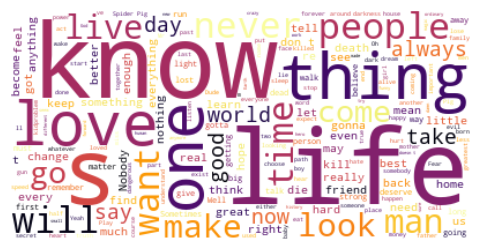

In [67]:
# join all our text from each row from our quote column into a string
text = " ".join(each for each in df.quote)

# generate our wordcloud image
wordcloud = WordCloud(background_color="white",
colormap = 'inferno').generate(text)

# use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, # remember 'imshow' from when we added pictures to our matplotlib axes
interpolation='bilinear') # this line helps smooth our image
ax.axis("off")

In [68]:
#Making venn diagrams
#We can use the matplotlib_venn extension to make venn diagrams
#First import the package

!pip install matplotlib-venn
import matplotlib_venn
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted



c:\Users\efren\miniconda3\envs\dsi_participant\lib\site-packages\matplotlib_venn\_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



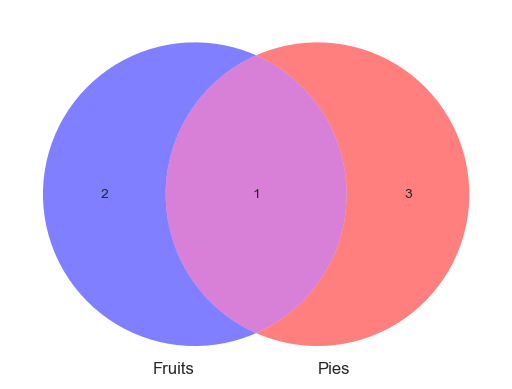

In [69]:
A = set(["apple","banana","watermelon"])
B = set(["pumpkin","blueberry","apple","key lime"])

#assign our sets to each circle and modify the appearance
diagram = venn2_unweighted([A, B],
                           set_labels = ('Fruits','Pies'),
                           set_colors=("blue","red"),
                           alpha=0.5)



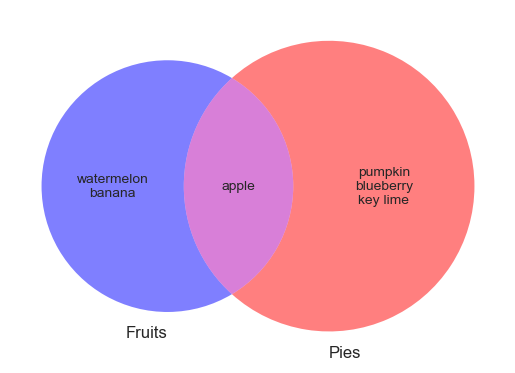

In [ ]:
#Modifying venn diagrams
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

A = set(["apple","banana","watermelon"])
B = set(["pumpkin","blueberry","apple","key lime"])

#assign our sets to each circle and modify the appearance
diagram = venn2([A, B],
                set_labels = ('Fruits','Pies'),
                set_colors=("blue","red"),
                alpha=0.5)

diagram.get_label_by_id("10").set_text("\n".join(A-B)) # add slash to not look crowded
diagram.get_label_by_id("11").set_text("\n".join(A&B))
diagram.get_label_by_id("01").set_text("\n".join(B-A))